Використай цей шаблон в роботі з датасетом. Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань. Обмежся функціями з наведених бібліотек.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

1. Завантаж датасет з бібліотеки seaborn:

In [2]:
# Завантажуємо датасет titanic з seaborn
df = sns.load_dataset('titanic')



2. Переглянь перші рядки датасету. Зроби висновок, чи коректно він завантажився.

In [3]:
df.head(8)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False


3. Перевір типи стовпців. Які з них потребують перетворення?

In [4]:
df.dtypes
# Які стовпці потребують перетворення?
cols_to_cat = ['sex', 'embarked', 'embark_town', 'who']
for c in cols_to_cat:
    df[c] = df[c].astype('category') #стать, місто посадки, категорія віку — це не числа, а групи


4. Перевір статистику по УСІМ стовпцям датасету.

In [5]:
# Статистика по всім стовпцям
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


5. Спробуй оцінити кількість дублікатів. Виміряй число рядків, позбудься дублікатів, оціни нову кількість рядків. Різницю виведи на екран, це і буде кількість рядків.

In [6]:
# Оцінка дублікатів
total_rows = len(df)
duplicates = df.duplicated().sum()
print(f'Усього рядків: {total_rows}\nДублікатів: {duplicates}')
# Видаляємо дублікти і дивимось на зміну
df_nodup = df.drop_duplicates()
new_rows = len(df_nodup)
print(f'Рядків після видалення дубліктів: {new_rows}')
print(f'Різниця (число видалених рядків): {total_rows - new_rows}')

Усього рядків: 891
Дублікатів: 107
Рядків після видалення дубліктів: 784
Різниця (число видалених рядків): 107


6. Необхідно створити єдиний стовпчик, що вказує кількість родичів для кожного пасажира на борту, замість:
Кількість братів/сестер або чоловіків/дружин на борту
Кількість батьків або дітей на борту
Булева ознака: True, якщо пасажир подорожував один (без родичів на борту)
після створення нового стовпчика, дропни попередні. Вони вже не потрібні.

In [9]:
#Створюємо новий стовпчик family_size
df['family_size'] = df['sibsp'] + df['parch']
#якщо family_size == 0 → alone == True
#якщо family_size > 0 → alone == False
df[['sibsp', 'parch', 'family_size', 'alone']].head(10)
#Видаляємо непотрібні стовпчики,вся інформація з них вже закладена у family_size
df.drop(columns=['sibsp', 'parch', 'alone'], inplace=True)
df.head()
df.columns


Index(['survived', 'pclass', 'sex', 'age', 'fare', 'embarked', 'class', 'who',
       'adult_male', 'deck', 'embark_town', 'alive', 'family_size'],
      dtype='object')

In [ ]:
7. Перевір частоту випадків за значеннями в  новому стовпчику (кількість родичів) використовуючи візуалізацію:

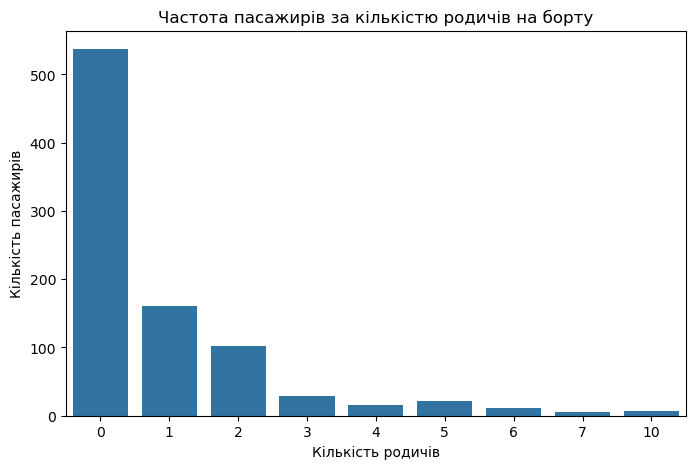

family_size
0     537
1     161
2     102
3      29
4      15
5      22
6      12
7       6
10      7
Name: count, dtype: int64

In [12]:
df['family_size'].head()
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='family_size')
plt.title('Частота пасажирів за кількістю родичів на борту')
plt.xlabel('Кількість родичів')
plt.ylabel('Кількість пасажирів')
plt.show()
df['family_size'].value_counts().sort_index()
#Найбільше пасажирів мали family_size = 0 → подорожували самі,зі збільшенням кількості родичів кількість пасажирів різко зменшується, пасажири з великими сім’ями (5+) — рідкісні випадки

8. Використовуючи лямбда функцію заміни кількість родичів, що перевищує число 5(п'ять) на значення "above 5"(понад п'ять):

In [44]:
#створюємо новий стовпчик
df['family_size_grouped'] = df['family_size'].apply(
    lambda x: 'above 5' if x > 5 else x
)
categories_order = [0, 1, 2, 3, 4, 5, 'above 5']
df['family_size_grouped'] = pd.Categorical(
    df['family_size_grouped'],
    categories=categories_order,
    ordered=True
)
     
df[['family_size', 'family_size_grouped']].tail(10)


,family_size,family_size_grouped
881,0,0
882,0,0
883,0,0
884,0,0
885,5,5
886,0,0
887,0,0
888,3,3
889,0,0
890,0,0


In [ ]:
9. Необхідно вивести на екран статистику по модифікованому стовпцю, віднісши нову категорію в кінець( для цього слід перетворити стовпець в категорійний):

In [43]:

df['family_size_grouped'].value_counts(sort=False)

family_size_grouped
0          537
1          161
2          102
3           29
4           15
5           22
above 5     25
Name: count, dtype: int64

10. Заповни відсутні значення віку медіаною.

In [22]:
df['age'].isna().sum()

age_median = df['age'].median()
age_median

df['age'] = df['age'].fillna(age_median)

df['age'].isna().sum()

np.int64(0)

11. Створи новий стовпець, де вік представлено категорією, замість числа (наприклад: до 14 років, 14-34 роки, 35-59 років, 60 і більше років). Виконай задачу з використанням користувацької функції. Осіб з невідомим віком познач відповідно.

In [25]:
#Створюємо користувацьку функцію категоризації віку
def age_to_category(age):
    if pd.isna(age):
        return 'unknown age'
    elif age < 14:
        return 'до 14 років'
    elif 14 <= age <= 34:
        return '14-34 роки'
    elif 35 <= age <= 59:
        return '35-59 років'
    else:
        return '60 і більше років'
#Створюємо новий стовпець із віковими категоріями
df['age_category'] = df['age'].apply(age_to_category)
#Перевіряємо результат
df[['age', 'age_category']].head(10)

,age,age_category
0,22.0,14-34 роки
1,38.0,35-59 років
2,26.0,14-34 роки
3,35.0,35-59 років
4,35.0,35-59 років
5,28.0,14-34 роки
6,54.0,35-59 років
7,2.0,до 14 років
8,27.0,14-34 роки
9,14.0,14-34 роки


12. Перевір, в якій віковій категорії була найвища смертність. Для цього рекомендується перетворити стовпець 'alive' в булевий тип. Потім підрахувати загальну кількість пасажирів та кількість тих, хто не вижив. Потім обчисли відносний показниках для кожної категорії.

In [31]:
#Перетворюємо стовпець alive у булевий тип
df['alive_bool'] = df['alive'].map({'yes': True, 'no': False})
df['alive_bool'].value_counts()
#Групуємо за віковими категоріями
mortality_stats = (
    df
    .groupby('age_category')
    .agg(
        total_passengers=('alive_bool', 'count'),
        dead_passengers=('alive_bool', lambda x: (~x).sum())
    )
)

mortality_stats['mortality_rate'] = (
    mortality_stats['dead_passengers'] /
    mortality_stats['total_passengers']
)
mortality_stats
#Визначаємо категорію з найвищою смертністю
mortality_stats['mortality_rate'].idxmax(), mortality_stats['mortality_rate'].max()
#найвищий відносний рівень смертності спостерігається у категорії 60 і більше років,найнижчий — у дітей (до 14 років), що узгоджується з принципом “women and children first”

('60 і більше років', 0.7407407407407407)

13. Відтвори cтатистику  смертності у вигляді кругової діаграми з розбивкою по віковим групам. Ти помітив, що відсотки відрізняються? Поясни чому.

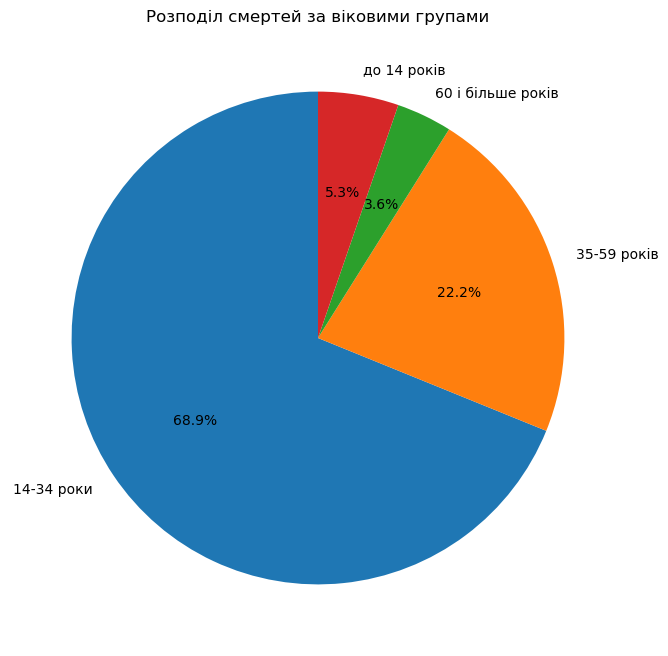

In [33]:
#Підготовка даних для кругової діаграми
dead_by_age = (
    df[df['alive_bool'] == False]
    .groupby('age_category')
    .size()
)
#Побудова кругової діаграми
plt.figure(figsize=(8, 8))
plt.pie(
    dead_by_age,
    labels=dead_by_age.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Розподіл смертей за віковими групами')
plt.show()
# Раніше ми рахували відносний рівень смертності:скільки % людей у кожній віковій групі загинуло,тут кругова діаграма показує:який % загиблих припадає на кожну вікову групу.
#Група 60+ може мати високу смертність (наприклад 70%)Але пасажирів там мало,тому на круговій діаграмі вона займає невеликий сектор.
#Група 14–34 роки має нижчий % смертності,але пасажирів дуже багато тому сектор на діаграмі великий






14. *Бонусне завдання*

Підготуй розгорнуту статистику смертності по категорії віку, класу квитка, рівню каюти та кількості родичів. Які фактори, на твою думку, найбільше пов'язані з рівнем смерності? (наприклад: найбільша смертність у відсотковому значенні спостерігається серед вікової групи ... класу квитка.... при наявності ... родичів та для рівня каюти.... Фактор ... має найвищий вплив на смертність)

In [40]:
#функція для розрахунку смертності
def mortality_table(df, group_col):
    table = (
        df
        .groupby(group_col,observed=True)
        .agg(
            total_passengers=('alive_bool', 'count'),
            dead_passengers=('alive_bool', lambda x: (~x).sum())
        )
    )
    table['mortality_rate'] = table['dead_passengers'] / table['total_passengers']
    return table.sort_values('mortality_rate', ascending=False)
#Смертність за віковою категорією
mortality_by_age = mortality_table(df, 'age_category')
mortality_by_age
#Найвища смертність в категорії 60+,найнижчя в категорії до 14 років,вік істотно впливає, діти мали пріоритет при евакуації.


,total_passengers,dead_passengers,mortality_rate
age_category,,,
60 і більше років,27,20,0.740741
14-34 роки,584,378,0.647260
35-59 років,209,122,0.583732
до 14 років,71,29,0.408451


In [41]:
#Смертність за класом квитка
mortality_by_class = mortality_table(df, 'class')
mortality_by_class
#Найвища смертність к ласі Third, найнижчя в First,соціально-економічний фактор мав дуже сильний вплив
(доступ до шлюпок, розташування кают).

,total_passengers,dead_passengers,mortality_rate
class,,,
Third,491,372,0.757637
Second,184,97,0.527174
First,216,80,0.370370


In [42]:
#Смертність за рівнем каюти (deck)
mortality_by_deck = mortality_table(df, 'deck')
mortality_by_deck
# фізичне розташування на кораблі напряму впливало на шанси виживання.

,total_passengers,dead_passengers,mortality_rate
deck,,,
A,15,8,0.533333
G,4,2,0.500000
C,59,24,0.406780
F,13,5,0.384615
B,47,12,0.255319
E,32,8,0.250000
D,33,8,0.242424


In [39]:
#Смертність за кількістю родичів
mortality_by_relatives = mortality_table(df, 'family_size')
mortality_by_relatives
#Найвища смертність серед пасажирів без родичів або з дуже великою кількістю (above 5)

,total_passengers,dead_passengers,mortality_rate
family_size,,,
7,6,6,1.000000
10,7,7,1.000000
5,22,19,0.863636
4,15,12,0.800000
0,537,374,0.696462
6,12,8,0.666667
1,161,72,0.447205
2,102,43,0.421569
3,29,8,0.275862


Висновок:
Найбільший вплив на смертність мав клас квитка, що відображає соціально-економічний статус і доступ до евакуації.
Значний вплив також мали вік пасажира та рівень каюти.
Кількість родичів виступає додатковим, але менш визначальним фактором.